In [30]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}


def gaussian(x, a, mu, c):
    return a * np.exp(-(x - mu)**2 / (2 * c**2))
def gaussianbg(x, a, mu, c, b):
    return a * np.exp(-(x - mu)**2 / (2 * c**2)) + b
def determine_peak(hist, index):
    if (
        (hist[index - 1] < hist[index]) &
        (hist[index - 2] < hist[index - 1]) &
        (hist[index - 3] < hist[index - 2])
    ):
        return True
    else:
        return False
# Function for finding photopeak, modified from ChannelPairBuilder.py
def findPhotopeak(hist, bins):
    photopeak = 0
    for i in range(1, len(hist)-4):
        #if hist[-1*i] > hist[-1*(i+1)] and hist[-1*i] > hist[-1*(i+2)] and hist[-1*i] >= 0.5 * np.max(hist):
        if determine_peak(hist, len(hist)-1*i):
            photopeak = len(hist)-1*i
            break
    fit_p = [0,1,1, 0]
    fit_x = list(bins[photopeak-5:photopeak+10])
    fit_y = list(hist[photopeak-5:photopeak+10])
    #print(fit_x, fit_y)
    if len(fit_x) != 0 and len(fit_y) != 0:
        try:
            fit_p, fit_co = curve_fit(gaussianbg, fit_x, fit_y, p0=[max(fit_y)*0.8, bins[photopeak], 2, fit_y[0]])
        except:
            print(f'Photopeak fit failed {id}')
    return fit_p

In [72]:
paths = [
    'Misc Data/linearity/bg.ldat',
    #'Misc Data/linearity/ba.ldat',
    'Misc Data/linearity/cs.ldat',
    #'Misc Data/linearity/na.ldat'
]
row_size = 16
idrange = list(range(64, 128)) + list(range(448, 512))
hists = [[] for _ in range(len(paths))]
bins = np.linspace(0, 30, 151)
bincenters = (bins[:-1] + bins[1:]) / 2
for i, path in enumerate(paths):
    num_rows = os.path.getsize(path) // row_size
    dtypes = np.dtype([('time', np.int64), 
                    ('energy', np.float32), 
                    ('id', np.int32)])
    data = np.memmap(path, dtype=dtypes, mode='r', shape=(num_rows,))
    for id in tqdm(idrange):
        chunk = data[data['id'] == id]
        hists[i].append(np.histogram(chunk['energy'], bins = bins)[0])


100%|██████████| 128/128 [00:27<00:00,  4.72it/s]


In [86]:
print(len(idrange))

128


56


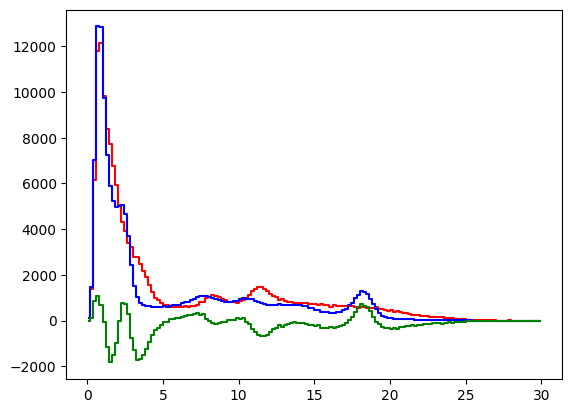

In [87]:
for row in range(8, 16):
    list_indices = dict(sorted(
        ((k, v) for k, v in indices.items() if v[0] == row),
        key=lambda item: item[1][1]
    ))
    for i in range(len(list_indices)):
        id = list(list_indices.keys())[i] % 64
        print(id)
        #scalefactor = np.max(hists[0][idrange[id]]) / np.max(hists[1][idrange[id]])
        scalefactor = 0.3
        plt.step(bincenters, hists[0][idrange[id]], where = 'mid', color = 'red')
        plt.step(bincenters, hists[1][idrange[id]] * scalefactor, where = 'mid', color = 'blue')
        plt.step(bincenters, hists[1][idrange[id]] * scalefactor - hists[0][idrange[id]], where = 'mid', color = 'green')
        #plt.step(bincenters, hists[2][idrange[id]], where = 'mid', color = 'green')
        #plt.step(bincenters, hists[3][idrange[id]], where = 'mid', color = 'orange')
        #plt.yscale('log')
        plt.show()
        break
    break